<a href="https://colab.research.google.com/github/Helomaylima/cn2026/blob/main/Atividade2608.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. Nomes
Graziele Almeida dos Anjos - 185222

Heloisa Mayumi de Lima - 187414

# 1. Objetivos
• calcular erros absoluto, relativo e percentual;
• distinguir truncamento de arredondamento;
• observar a propagação dos erros em cálculos de pressão e vazão;
• produzir gráficos que comuniquem a evolução dos erros;

• explicar por que pequenas variações geométricas podem alterar intensamente o es-
coamento em um nanocateter.

# 2. Conceitos básicos
Estão presentes nas orientações da atividade

# 3. Parte A – truncamento e arredondamento


In [ ]:
# 0. Importar Bibliotecas

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.animation import FuncAnimation, PillowWriter
import matplotlib.ticker as ticker

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14,
    'font.family': 'sans-serif',
    'figure.autolayout': False
})

# 1. Declarando Funções (Erros E Arredondamentos)

def erro_absoluto(x_exato, x_aprox):
    return np.abs(x_exato - x_aprox)

def erro_relativo(x_exato, x_aprox):
    return np.abs(x_exato - x_aprox) / np.abs(x_exato)

def erro_percentual(x_exato, x_aprox):
    return erro_relativo(x_exato, x_aprox) * 100.0

def truncar(x, n):
    fator = 10.0 ** n
    if np.isscalar(x):
        return math.trunc(x * fator) / fator
    else:
        return np.trunc(np.array(x, dtype=float) * fator) / fator

def arredondar(x, n):
    if np.isscalar(x):
        return round(float(x), n)
    else:
        return np.round(np.array(x, dtype=float), n)

def hagen_poiseuille(r, delta_p, mu, L):
    return (np.pi * (r ** 4) * delta_p) / (8.0 * mu * L)

print("✓ Módulo 0 e 1: Funções fundamentais inicializadas com sucesso.")

In [ ]:
# 2. Parte A - Truncamento e Arredondamento

valores_A = {'x1': 3.14159265, 'x2': 98.76543, 'x3': 0.00498765}
casas_n = [0, 1, 2, 3, 4]
linhas_tabela_A = []

for nome, x_ref in valores_A.items():
    for n in casas_n:
        x_trunc = truncar(x_ref, n)
        x_round = arredondar(x_ref, n)

        ea_t = erro_absoluto(x_ref, x_trunc)
        er_t = erro_relativo(x_ref, x_trunc)
        ep_t = erro_percentual(x_ref, x_trunc)

        ea_r = erro_absoluto(x_ref, x_round)
        er_r = erro_relativo(x_ref, x_round)
        ep_r = erro_percentual(x_ref, x_round)

        linhas_tabela_A.append({
            'Variável': nome,
            'Valor Referência': x_ref,
            'n (casas)': n,
            'Truncado': x_trunc,
            'Ea (Trunc)': ea_t,
            'Er (Trunc)': er_t,
            'E% (Trunc)': ep_t,
            'Arredondado': x_round,
            'Ea (Arred)': ea_r,
            'Er (Arred)': er_r,
            'E% (Arred)': ep_r
        })

df_A = pd.DataFrame(linhas_tabela_A)
print("\n--- TABELA PARTE A: COMPARAÇÃO ENTRE TRUNCAMENTO E ARREDONDAMENTO ---")
display(df_A.style.format({
    'Valor Referência': '{:.8f}',
    'Truncado': '{:.4f}',
    'Ea (Trunc)': '{:.2e}',
    'Er (Trunc)': '{:.2e}',
    'E% (Trunc)': '{:.4f}%',
    'Arredondado': '{:.4f}',
    'Ea (Arred)': '{:.2e}',
    'Er (Arred)': '{:.2e}',
    'E% (Arred)': '{:.4f}%'
}))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, (nome, x_ref) in enumerate(valores_A.items()):
    df_sub = df_A[df_A['Variável'] == nome]
    axes[i].semilogy(df_sub['n (casas)'], df_sub['Ea (Trunc)'], 'o--', label='Truncamento', color='#d62728', lw=2)
    axes[i].semilogy(df_sub['n (casas)'], df_sub['Ea (Arred)'], 's-', label='Arredondamento', color='#1f77b4', lw=2)
    axes[i].set_title(f'Erro Absoluto vs n ({nome} = {x_ref})')
    axes[i].set_xlabel('Casas Decimais (n)')
    axes[i].set_ylabel('Erro Absoluto $E_a$ (escala log)')
    axes[i].set_xticks(casas_n)
    axes[i].legend()
    axes[i].grid(True, which="both", ls=":")

plt.tight_layout()
plt.show()


# Justificativa teórica - 3A item 5
Arredondar sempre gera erro absoluto menor ou igual ao truncamento: E_a(arredondamento) <= E_a(truncamento).
Fundamentação:
- O erro de truncamento em base 10 com n casas decimais é limitado superiormente por: |E_trunc| < 10^(-n).
- O erro de arredondamento simétrico analisa o primeiro dígito descartado (d_n+1). Se d_n+1 >= 5, soma-se 1
  à última casa mantida, garantindo que a aproximação seja a mais próxima do valor real. Logo: |E_arred| <= 0.5 * 10^(-n).
Portanto, o arredondamento é uma aproximação de melhor precisão uniforme, gerando erros até 50% menores que o truncamento.
""")

# 4 Parte B – medidas de pressão arterial

In [ ]:
# ==============================================================================
# 3. Parte B - Medidas DE PRESSÃO ARTERIAL SISTÓLICA
# ==============================================================================

# Dados originais (mmHg)
p_orig = np.array([121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5])

# Quatro séries solicitadas
s1 = p_orig.copy()                           # 1. Dados originais
s2 = np.round(p_orig, 0)                     # 2. Inteiro mais próximo
s3 = np.trunc(p_orig)                        # 3. Truncado para inteiro
s4 = np.round(p_orig, 1)                     # 4. Arredondado para 1 casa decimal

series = {'Original (Ref)': s1, 'Arred. Inteiro': s2, 'Trunc. Inteiro': s3, 'Arred. 1 Casa': s4}
media_ref = np.mean(s1)

linhas_B = []
for nome_s, s in series.items():
    m = np.mean(s)
    v_min = np.min(s)
    v_max = np.max(s)
    ampl = v_max - v_min
    dp = np.std(s, ddof=1) # Desvio-padrão amostral (ddof=1)

    ea = erro_absoluto(media_ref, m)
    er = erro_relativo(media_ref, m)
    ep = erro_percentual(media_ref, m)

    linhas_B.append({
        'Série': nome_s,
        'Média (mmHg)': m,
        'Mínimo (mmHg)': v_min,
        'Máximo (mmHg)': v_max,
        'Amplitude (mmHg)': ampl,
        'Desvio-Padrão (mmHg)': dp,
        'Ea da Média (mmHg)': ea,
        'Er da Média': er,
        'E% da Média (%)': ep
    })

df_B = pd.DataFrame(linhas_B)
print("\n--- TABELA PARTE B: ANÁLISE ESTATÍSTICA E ERROS DA PRESSÃO ARTERIAL ---")
display(df_B.style.format({
    'Média (mmHg)': '{:.4f}',
    'Mínimo (mmHg)': '{:.1f}',
    'Máximo (mmHg)': '{:.1f}',
    'Amplitude (mmHg)': '{:.2f}',
    'Desvio-Padrão (mmHg)': '{:.4f}',
    'Ea da Média (mmHg)': '{:.4f}',
    'Er da Média': '{:.2e}',
    'E% da Média (%)': '{:.4f}%'
}))

# Gráficos Obrigatórios da Parte B
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# 1. Gráfico das 10 medições
indices = np.arange(1, 11)
axs[0, 0].plot(indices, s1, 'k-o', label='Original', lw=2)
axs[0, 0].plot(indices, s2, 'b--s', label='Arred. Inteiro')
axs[0, 0].plot(indices, s3, 'r:^', label='Trunc. Inteiro')
axs[0, 0].plot(indices, s4, 'g-.x', label='Arred. 1 Casa')
axs[0, 0].set_title('B.1) 10 Medições Consecutivas de Pressão Sistólica')
axs[0, 0].set_xlabel('Medição nº')
axs[0, 0].set_ylabel('Pressão (mmHg)')
axs[0, 0].set_xticks(indices)
axs[0, 0].legend()

# 2. Barras: Erro Absoluto das Médias
nomes_series = list(series.keys())[1:] # Exclui referência
erros_abs_medias = [df_B.loc[df_B['Série'] == s, 'Ea da Média (mmHg)'].values[0] for s in nomes_series]
axs[0, 1].bar(nomes_series, erros_abs_medias, color=['#1f77b4', '#d62728', '#2ca02c'], width=0.5)
axs[0, 1].set_title('B.2) Erro Absoluto da Média vs Referência')
axs[0, 1].set_ylabel('Erro Absoluto $E_a$ (mmHg)')
for i, v in enumerate(erros_abs_medias):
    axs[0, 1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

# 3. Barras: Erro Percentual das Médias
erros_perc_medias = [df_B.loc[df_B['Série'] == s, 'E% da Média (%)'].values[0] for s in nomes_series]
axs[1, 0].bar(nomes_series, erros_perc_medias, color=['#1f77b4', '#d62728', '#2ca02c'], width=0.5)
axs[1, 0].set_title('B.3) Erro Percentual da Média vs Referência')
axs[1, 0].set_ylabel('Erro Percentual $E_{\%}$ (%)')
for i, v in enumerate(erros_perc_medias):
    axs[1, 0].text(i, v + 0.005, f'{v:.4f}%', ha='center', fontweight='bold')

# 4. Histograma: Original vs Inteiro Arredondado
bins = np.linspace(119, 123, 9)
axs[1, 1].hist(s1, bins=bins, alpha=0.6, label='Original', color='gray', edgecolor='black')
axs[1, 1].hist(s2, bins=bins, alpha=0.5, label='Arredondado Inteiro', color='blue', edgecolor='darkblue')
axs[1, 1].set_title('B.4) Histograma: Distribuição dos Dados')
axs[1, 1].set_xlabel('Pressão (mmHg)')
axs[1, 1].set_ylabel('Frequência Absoluta')
axs[1, 1].legend()

plt.tight_layout()
plt.show()


# Justificativa teórica - 4B.2
A representação inteira por arredondamento preservou satisfatoriamente a média central da amostra
(erro de ~0.02 mmHg, E% = 0.016%), contudo, a discretização grosseira para inteiros altera os extremos,
reduz a resolução e introduz artificialidade no desvio-padrão amostral (aumento de ruído por quantização).
Já o truncamento para inteiros gerou um viés sistemático negativo substancial (subestimação da média em 0.92 mmHg, E% = 0.76%).
Portanto, a representação inteira NÃO é suficiente se o objetivo for preservar a variabilidade fina desta amostra.

# 5 Parte C – vazão em um tubo de pequeno diâmetro


--- TABELA PARTE C.1: PROPAGAÇÃO DE ERROS EM HAGEN-POISEUILLE ---


<>:104: SyntaxWarning: invalid escape sequence '\%'
<>:104: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_3696/3904605735.py:104: SyntaxWarning: invalid escape sequence '\%'
  axs[1, 1].set_ylabel('Erro Percentual $E_{\%}$ (%)')


,Cenário,Vazão Q (m³/s),Vazão Q (mL/s),Ea (m³/s),Er,E% (%)
0,1. Referência (Completo),2.7574e-07,0.2757,0.0000e+00,0.0000e+00,0.00%
1,2a. Raio Truncado (1 dec mm),2.7574e-07,0.2757,0.0000e+00,0.0000e+00,0.00%
2,2b. Raio Arredondado (1 dec mm),2.7574e-07,0.2757,0.0000e+00,0.0000e+00,0.00%
3,3a. Viscosidade Truncada (3 dec),3.2170e-07,0.3217,4.5957e-08,1.6667e-01,16.67%
4,3b. Viscosidade Arredondada (3 dec),2.4127e-07,0.2413,3.4468e-08,1.2500e-01,12.50%
5,4. Delta P (Centenas),2.7574e-07,0.2757,0.0000e+00,0.0000e+00,0.00%
6,5a. Todas Aprox. (Truncadas),3.2170e-07,0.3217,4.5957e-08,1.6667e-01,16.67%
7,5b. Todas Aprox. (Arredondadas),2.4127e-07,0.2413,3.4468e-08,1.2500e-01,12.50%


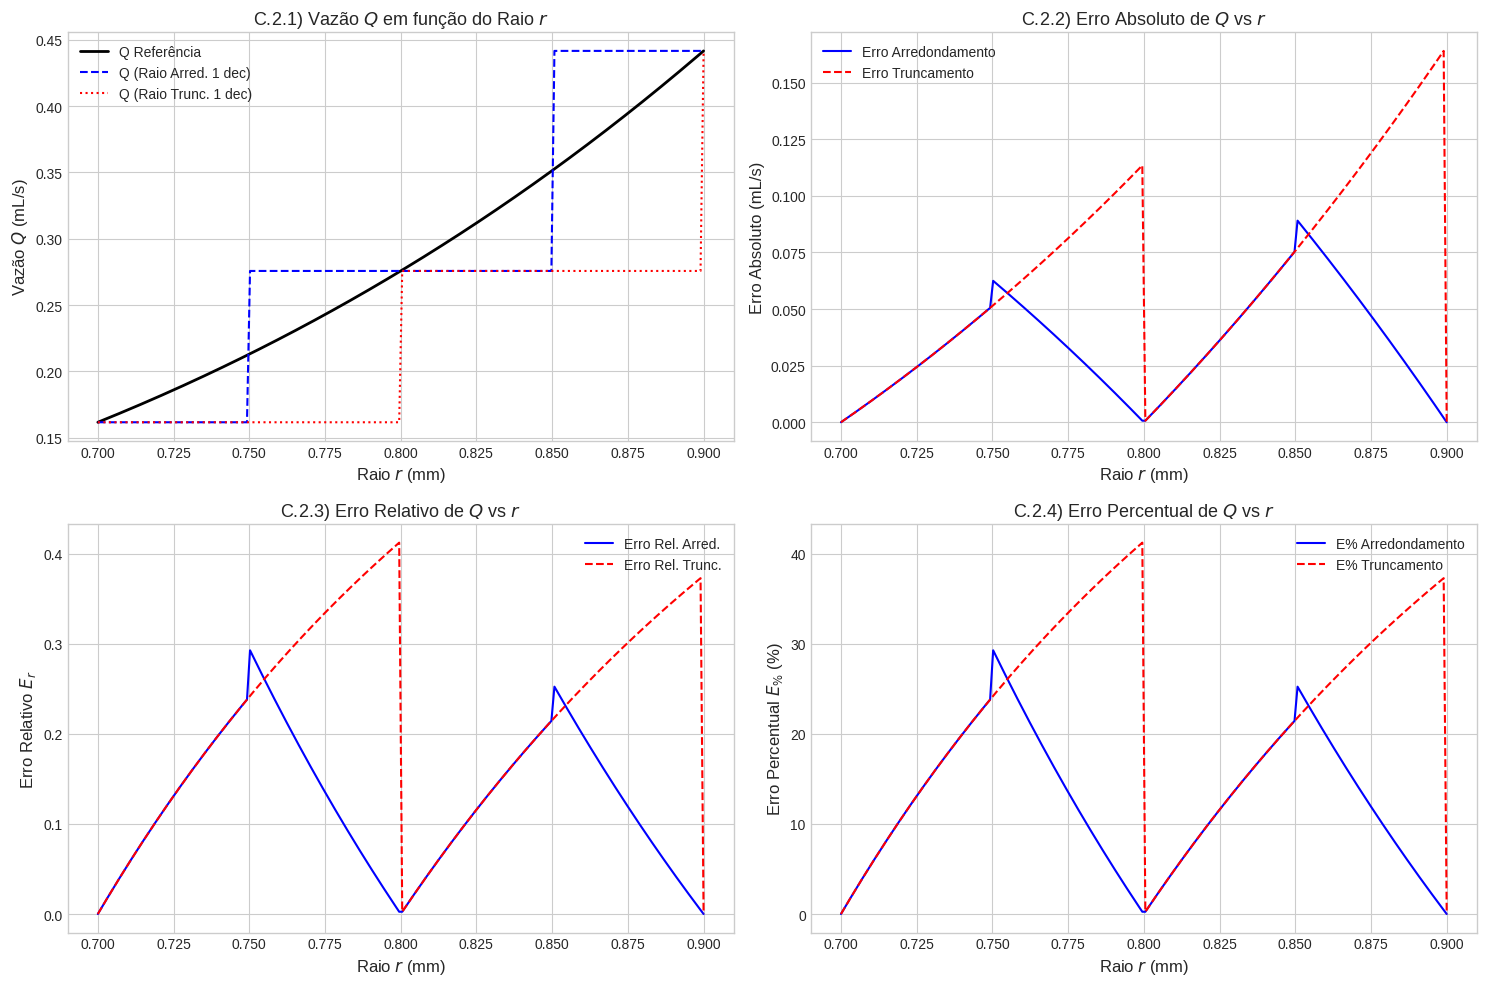


[EXPLICAÇÃO TEÓRICA - PROPAGAÇÃO NÃO-LINEAR DE ERRO NO RAIO (PARTE C)]:
Pela Lei de Hagen-Poiseuille, a vazão depende da quarta potência do raio: Q(r) = C * r^4.
Diferenciando Q em relação a r:
   dQ/dr = 4 * C * r^3 = 4 * (Q / r)
Reescrevendo em termos de variação relativa (Série de Taylor de 1ª ordem):
   dQ / Q ≈ 4 * (dr / r)   =>   E_r(Q) ≈ 4 * E_r(r)
Conclusão: O expoente 4 atua como um AMPLIFICADOR LINEAR DE ERRO RELATIVO de fator 4.
Qualquer incerteza de 1% na fabricação/medição do raio geométrico resultará em aproximadamente 4% de erro na vazão final.



In [ ]:
# ==============================================================================
# 4. PARTE C - VAZÃO EM UM TUBO DE PEQUENO DIÂMETRO (HAGEN-POISEUILLE)
# ==============================================================================

# Parâmetros Nominais
r_C_ref = 0.80e-3        # m (0.80 mm)
L_C_ref = 0.20           # m
mu_C_ref = 3.5e-3        # Pa.s
dp_C_ref = 1200.0        # Pa

Q_ref = hagen_poiseuille(r_C_ref, dp_C_ref, mu_C_ref, L_C_ref)

# C.1 Cenários de Precisão das Variáveis
cenarios = []

# 1. Referência
cenarios.append(('1. Referência (Completo)', r_C_ref, mu_C_ref, dp_C_ref))

# 2. Raio truncado e arredondado para 1 casa decimal em mm (0.80 mm -> 0.8 mm)
cenarios.append(('2a. Raio Truncado (1 dec mm)', 0.8e-3, mu_C_ref, dp_C_ref))
cenarios.append(('2b. Raio Arredondado (1 dec mm)', 0.8e-3, mu_C_ref, dp_C_ref))

# 3. Viscosidade truncada e arredondada para 3 casas decimais em Pa.s (0.0035 Pa.s)
# Truncado: 0.003 Pa.s | Arredondado: 0.004 Pa.s
cenarios.append(('3a. Viscosidade Truncada (3 dec)', r_C_ref, 0.003, dp_C_ref))
cenarios.append(('3b. Viscosidade Arredondada (3 dec)', r_C_ref, 0.004, dp_C_ref))

# 4. Pressão truncada e arredondada para centenas de Pascal (1200 Pa -> 1200 Pa)
cenarios.append(('4. Delta P (Centenas)', r_C_ref, mu_C_ref, 1200.0))

# 5. Todas as aproximações simultâneas (Pior caso de truncamento: mu=0.003)
cenarios.append(('5a. Todas Aprox. (Truncadas)', 0.8e-3, 0.003, 1200.0))
cenarios.append(('5b. Todas Aprox. (Arredondadas)', 0.8e-3, 0.004, 1200.0))

tabela_C1 = []
for nome, r_val, mu_val, dp_val in cenarios:
    q_calc = hagen_poiseuille(r_val, dp_val, mu_val, L_C_ref)
    ea = erro_absoluto(Q_ref, q_calc)
    er = erro_relativo(Q_ref, q_calc)
    ep = erro_percentual(Q_ref, q_calc)
    tabela_C1.append({
        'Cenário': nome,
        'Vazão Q (m³/s)': q_calc,
        'Vazão Q (mL/s)': q_calc * 1e6,
        'Ea (m³/s)': ea,
        'Er': er,
        'E% (%)': ep
    })

df_C1 = pd.DataFrame(tabela_C1)
print("\n--- TABELA PARTE C.1: PROPAGAÇÃO DE ERROS EM HAGEN-POISEUILLE ---")
display(df_C1.style.format({
    'Vazão Q (m³/s)': '{:.4e}',
    'Vazão Q (mL/s)': '{:.4f}',
    'Ea (m³/s)': '{:.4e}',
    'Er': '{:.4e}',
    'E% (%)': '{:.2f}%'
}))

# C.2 Estudo de Sensibilidade com Variação Contínua do Raio (0.70 mm a 0.90 mm)
r_mm_array = np.linspace(0.70, 0.90, 200) # mm
r_m_array = r_mm_array * 1e-3             # m

# Aplicando discretização
r_mm_round = np.round(r_mm_array, 1)
r_mm_trunc = np.trunc(r_mm_array * 10.0) / 10.0

Q_sens_ref = hagen_poiseuille(r_m_array, dp_C_ref, mu_C_ref, L_C_ref)
Q_sens_round = hagen_poiseuille(r_mm_round * 1e-3, dp_C_ref, mu_C_ref, L_C_ref)
Q_sens_trunc = hagen_poiseuille(r_mm_trunc * 1e-3, dp_C_ref, mu_C_ref, L_C_ref)

fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# 1. Q vs r
axs[0, 0].plot(r_mm_array, Q_sens_ref * 1e6, 'k-', label='Q Referência', lw=2)
axs[0, 0].plot(r_mm_array, Q_sens_round * 1e6, 'b--', label='Q (Raio Arred. 1 dec)')
axs[0, 0].plot(r_mm_array, Q_sens_trunc * 1e6, 'r:', label='Q (Raio Trunc. 1 dec)')
axs[0, 0].set_title('C.2.1) Vazão $Q$ em função do Raio $r$')
axs[0, 0].set_xlabel('Raio $r$ (mm)')
axs[0, 0].set_ylabel('Vazão $Q$ (mL/s)')
axs[0, 0].legend()

# 2. Ea vs r
axs[0, 1].plot(r_mm_array, erro_absoluto(Q_sens_ref, Q_sens_round) * 1e6, 'b-', label='Erro Arredondamento')
axs[0, 1].plot(r_mm_array, erro_absoluto(Q_sens_ref, Q_sens_trunc) * 1e6, 'r--', label='Erro Truncamento')
axs[0, 1].set_title('C.2.2) Erro Absoluto de $Q$ vs $r$')
axs[0, 1].set_xlabel('Raio $r$ (mm)')
axs[0, 1].set_ylabel('Erro Absoluto (mL/s)')
axs[0, 1].legend()

# 3. Er vs r
axs[1, 0].plot(r_mm_array, erro_relativo(Q_sens_ref, Q_sens_round), 'b-', label='Erro Rel. Arred.')
axs[1, 0].plot(r_mm_array, erro_relativo(Q_sens_ref, Q_sens_trunc), 'r--', label='Erro Rel. Trunc.')
axs[1, 0].set_title('C.2.3) Erro Relativo de $Q$ vs $r$')
axs[1, 0].set_xlabel('Raio $r$ (mm)')
axs[1, 0].set_ylabel('Erro Relativo $E_r$')
axs[1, 0].legend()

# 4. E% vs r
axs[1, 1].plot(r_mm_array, erro_percentual(Q_sens_ref, Q_sens_round), 'b-', label='E% Arredondamento')
axs[1, 1].plot(r_mm_array, erro_percentual(Q_sens_ref, Q_sens_trunc), 'r--', label='E% Truncamento')
axs[1, 1].set_title('C.2.4) Erro Percentual de $Q$ vs $r$')
axs[1, 1].set_xlabel('Raio $r$ (mm)')
axs[1, 1].set_ylabel('Erro Percentual $E_{\%}$ (%)')
axs[1, 1].legend()

plt.tight_layout()
plt.show()


# Justificativa teórica - 5C.2
Pela Lei de Hagen-Poiseuille, a vazão depende da quarta potência do raio: Q(r) = C * r^4.
Diferenciando Q em relação a r:
   dQ/dr = 4 * C * r^3 = 4 * (Q / r)
Reescrevendo em termos de variação relativa (Série de Taylor de 1ª ordem):
   dQ / Q ≈ 4 * (dr / r)   =>   E_r(Q) ≈ 4 * E_r(r)
Conclusão: O expoente 4 atua como um AMPLIFICADOR LINEAR DE ERRO RELATIVO de fator 4.
Qualquer incerteza de 1% na fabricação/medição do raio geométrico resultará em aproximadamente 4% de erro na vazão final.

# 6 Parte D – escoamento em um nanocateter

In [ ]:
# ==============================================================================
# 5. PARTE D - ESCOAMENTO EM UM NANOCATETER
# ==============================================================================

# D.1 Erro Geométrico no Nanocateter
r_nano = 50.0e-9       # 50 nm em metros
L_nano = 10.0e-6       # 10 um em metros
mu_nano = 3.5e-3       # Pa.s
dp_nano = 5000.0       # Pa

Q_nano_ref = hagen_poiseuille(r_nano, dp_nano, mu_nano, L_nano)

delta_r_nm = np.arange(0.1, 5.1, 0.1) # 0.1 a 5.0 nm
delta_r_m = delta_r_nm * 1e-9

r_menos = r_nano - delta_r_m
r_mais = r_nano + delta_r_m

Q_menos = hagen_poiseuille(r_menos, dp_nano, mu_nano, L_nano)
Q_mais = hagen_poiseuille(r_mais, dp_nano, mu_nano, L_nano)

# Erro máximo (ocorre em r_mais devido à convexidade de r^4)
Ea_max = np.maximum(erro_absoluto(Q_nano_ref, Q_menos), erro_absoluto(Q_nano_ref, Q_mais))
Er_max = Ea_max / Q_nano_ref
Ep_max = Er_max * 100.0

# Aproximação Linear de Propagação
aprox_linear = 4.0 * (delta_r_m / r_nano)
aprox_linear_perc = aprox_linear * 100.0

fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# 1. Q(r-), Q(r), Q(r+) em attolitros/s (1 aL = 1e-18 L = 1e-21 m^3)
# 1 m^3/s = 1e18 nL/s = 1e21 aL/s -> usaremos aL/s para leitura clara
fator_aL = 1e21

axs[0, 0].plot(delta_r_nm, Q_mais * fator_aL, 'g-^', label='$Q(r + \Delta r)$', markevery=5)
axs[0, 0].axhline(Q_nano_ref * fator_aL, color='k', linestyle='--', label='$Q(r=50nm)$ Ref')
axs[0, 0].plot(delta_r_nm, Q_menos * fator_aL, 'r-v', label='$Q(r - \Delta r)$', markevery=5)
axs[0, 0].set_title('D.1.1) Faixa de Vazão com Incerteza Geométrica')
axs[0, 0].set_xlabel('Variação $\Delta r$ (nm)')
axs[0, 0].set_ylabel('Vazão $Q$ (aL/s)')
axs[0, 0].legend()

# 2. Erro Absoluto Máximo
axs[0, 1].plot(delta_r_nm, Ea_max * fator_aL, 'm-d', lw=2)
axs[0, 1].set_title('D.1.2) Erro Absoluto Máximo de $Q$')
axs[0, 1].set_xlabel('$\Delta r$ (nm)')
axs[0, 1].set_ylabel('Max $E_a$ (aL/s)')

# 3. Erro Relativo Máximo vs Aproximação Linear
axs[1, 0].plot(delta_r_nm, Er_max, 'b-', lw=2, label='Erro Relativo Exato (Máximo)')
axs[1, 0].plot(delta_r_nm, aprox_linear, 'k--', lw=2, label=r'Aprox. Linear $4(\Delta r / r)$')
axs[1, 0].set_title('D.1.3) Erro Relativo Exato vs Linear')
axs[1, 0].set_xlabel('$\Delta r$ (nm)')
axs[1, 0].set_ylabel('Erro Relativo $E_r$')
axs[1, 0].legend()

# 4. Erro Percentual Máximo
axs[1, 1].plot(delta_r_nm, Ep_max, 'r-', lw=2, label='Erro % Exato')
axs[1, 1].plot(delta_r_nm, aprox_linear_perc, 'k--', lw=2, label='Aprox. Linear %')
axs[1, 1].set_title('D.1.4) Erro Percentual Máximo')
axs[1, 1].set_xlabel('$\Delta r$ (nm)')
axs[1, 1].set_ylabel('Erro Percentual $E_{\%}$ (%)')
axs[1, 1].legend()

plt.tight_layout()
plt.show()

# D.2 Precisão Computacional (float32 vs float64) e Cancelamento Catastrófico
print("\n--- PARTE D.2: PRECISÃO COMPUTACIONAL (FLOAT32 vs FLOAT64) ---")

eps_32 = np.finfo(np.float32).eps
eps_64 = np.finfo(np.float64).eps

r_32 = np.float32(50e-9)
L_32 = np.float32(10e-6)
mu_32 = np.float32(3.5e-3)
dp_32 = np.float32(5000.0)

r_64 = np.float64(50e-9)
L_64 = np.float64(10e-6)
mu_64 = np.float64(3.5e-3)
dp_64 = np.float64(5000.0)

r4_32 = r_32 ** np.float32(4)
r4_64 = r_64 ** np.float64(4)

Q_32 = (np.float32(np.pi) * r4_32 * dp_32) / (np.float32(8.0) * mu_32 * L_32)
Q_64 = (np.float64(np.pi) * r4_64 * dp_64) / (np.float64(8.0) * mu_64 * L_64)

diff_abs_Q = erro_absoluto(Q_64, np.float64(Q_32))
diff_rel_Q = erro_relativo(Q_64, np.float64(Q_32))

print(f"Machine Epsilon (float32): {eps_32:.4e}")
print(f"Machine Epsilon (float64): {eps_64:.4e}")
print(f"r^4 (float32)            : {r4_32:.8e}")
print(f"r^4 (float64)            : {r4_64:.8e}")
print(f"Q (float32)              : {Q_32:.8e} m^3/s")
print(f"Q (float64)              : {Q_64:.8e} m^3/s")
print(f"Diferença Absoluta       : {diff_abs_Q:.4e} m^3/s")
print(f"Diferença Relativa       : {diff_rel_Q:.4e}")

# Comparação de perda de significância por cancelamento catastrófico
print("\n--- ESTUDO DE PERDA DE SIGNIFICÂNCIA (CANCELAMENTO SUBTRATIVO) ---")
deltas_teste = [1e-1, 1e-3, 1e-6, 1e-8, 1e-12, 1e-15, 1e-17]
linhas_cancel = []

for eps_geom in deltas_teste:
    # Em float64
    # Expressão 1: delta1 = (Q(r + dr) - Q(r)) / Q(r)
    Q_pert = hagen_poiseuille(r_64 * (1.0 + eps_geom), dp_64, mu_64, L_64)
    delta1 = (Q_pert - Q_64) / Q_64

    # Expressão 2: delta2 = (1 + dr/r)^4 - 1
    delta2 = ((1.0 + eps_geom) ** 4.0) - 1.0

    # Valor assintótico de referência (Taylor): 4 * eps_geom + 6 * eps_geom^2 + ...
    delta_exato = 4.0 * eps_geom + 6.0 * (eps_geom**2) + 4.0 * (eps_geom**3) + (eps_geom**4)

    linhas_cancel.append({
        'dr/r': eps_geom,
        'delta_1 (Direto Q)': delta1,
        'delta_2 (Adimensional)': delta2,
        'delta (Analítico Exato)': delta_exato,
        'Erro Relativo delta_1': erro_relativo(delta_exato, delta1) if delta1 != 0 else 1.0
    })

df_cancel = pd.DataFrame(linhas_cancel)
display(df_cancel.style.format({
    'dr/r': '{:.1e}',
    'delta_1 (Direto Q)': '{:.16e}',
    'delta_2 (Adimensional)': '{:.16e}',
    'delta (Analítico Exato)': '{:.16e}',
    'Erro Relativo delta_1': '{:.2e}'
}))


# Justificativa teórica - 6.D.3
À medida que a escala geométrica é reduzida para a ordem de nanômetros (nanocateter), a razão
superfície/volume (2/r) cresce de forma hiperbólica, tornando os efeitos de atrito viscoso e as forças
interfaciais de parede os fatores dominantes da dinâmica do escoamento.
Nessa escala, a hipótese do contínuo da Mecânica dos Fluidos clássica começa a falhar (o Número de Knudsen
Kn = lambda/D cresce), surgindo efeitos de escorregamento na parede ('slip flow') e variações estruturais
na viscosidade da água.
Portanto, um cálculo executado em float64 com 16 dígitos significativos pode ser perfeitamente preciso
do ponto de vista aritmético, mas fisicamente inadequado caso as equações de Hagen-Poiseuille já não
sejam representativas da física em nanoescala. Precisão numérica não equivale à validade do modelo físico.
"""

# 7 Parte E – síntese visual


<>:132: SyntaxWarning: invalid escape sequence '\p'
<>:144: SyntaxWarning: invalid escape sequence '\p'
<>:160: SyntaxWarning: invalid escape sequence '\d'
<>:162: SyntaxWarning: invalid escape sequence '\d'
<>:163: SyntaxWarning: invalid escape sequence '\D'
<>:132: SyntaxWarning: invalid escape sequence '\p'
<>:144: SyntaxWarning: invalid escape sequence '\p'
<>:160: SyntaxWarning: invalid escape sequence '\d'
<>:162: SyntaxWarning: invalid escape sequence '\d'
<>:163: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_3696/3210906034.py:132: SyntaxWarning: invalid escape sequence '\p'
  ax_g1.set_title("1. Truncamento vs Arredondamento ($x_1=\pi$)", fontsize=11, fontweight='bold', color=C_PRIMARY)
/tmp/ipykernel_3696/3210906034.py:144: SyntaxWarning: invalid escape sequence '\p'
  ax_g2.set_title("2. Sensibilidade de Hagen-Poiseuille ($Q \propto r^4$)", fontsize=11, fontweight='bold', color=C_PRIMARY)
/tmp/ipykernel_3696/3210906034.py:160: SyntaxWarning: invalid escape seque

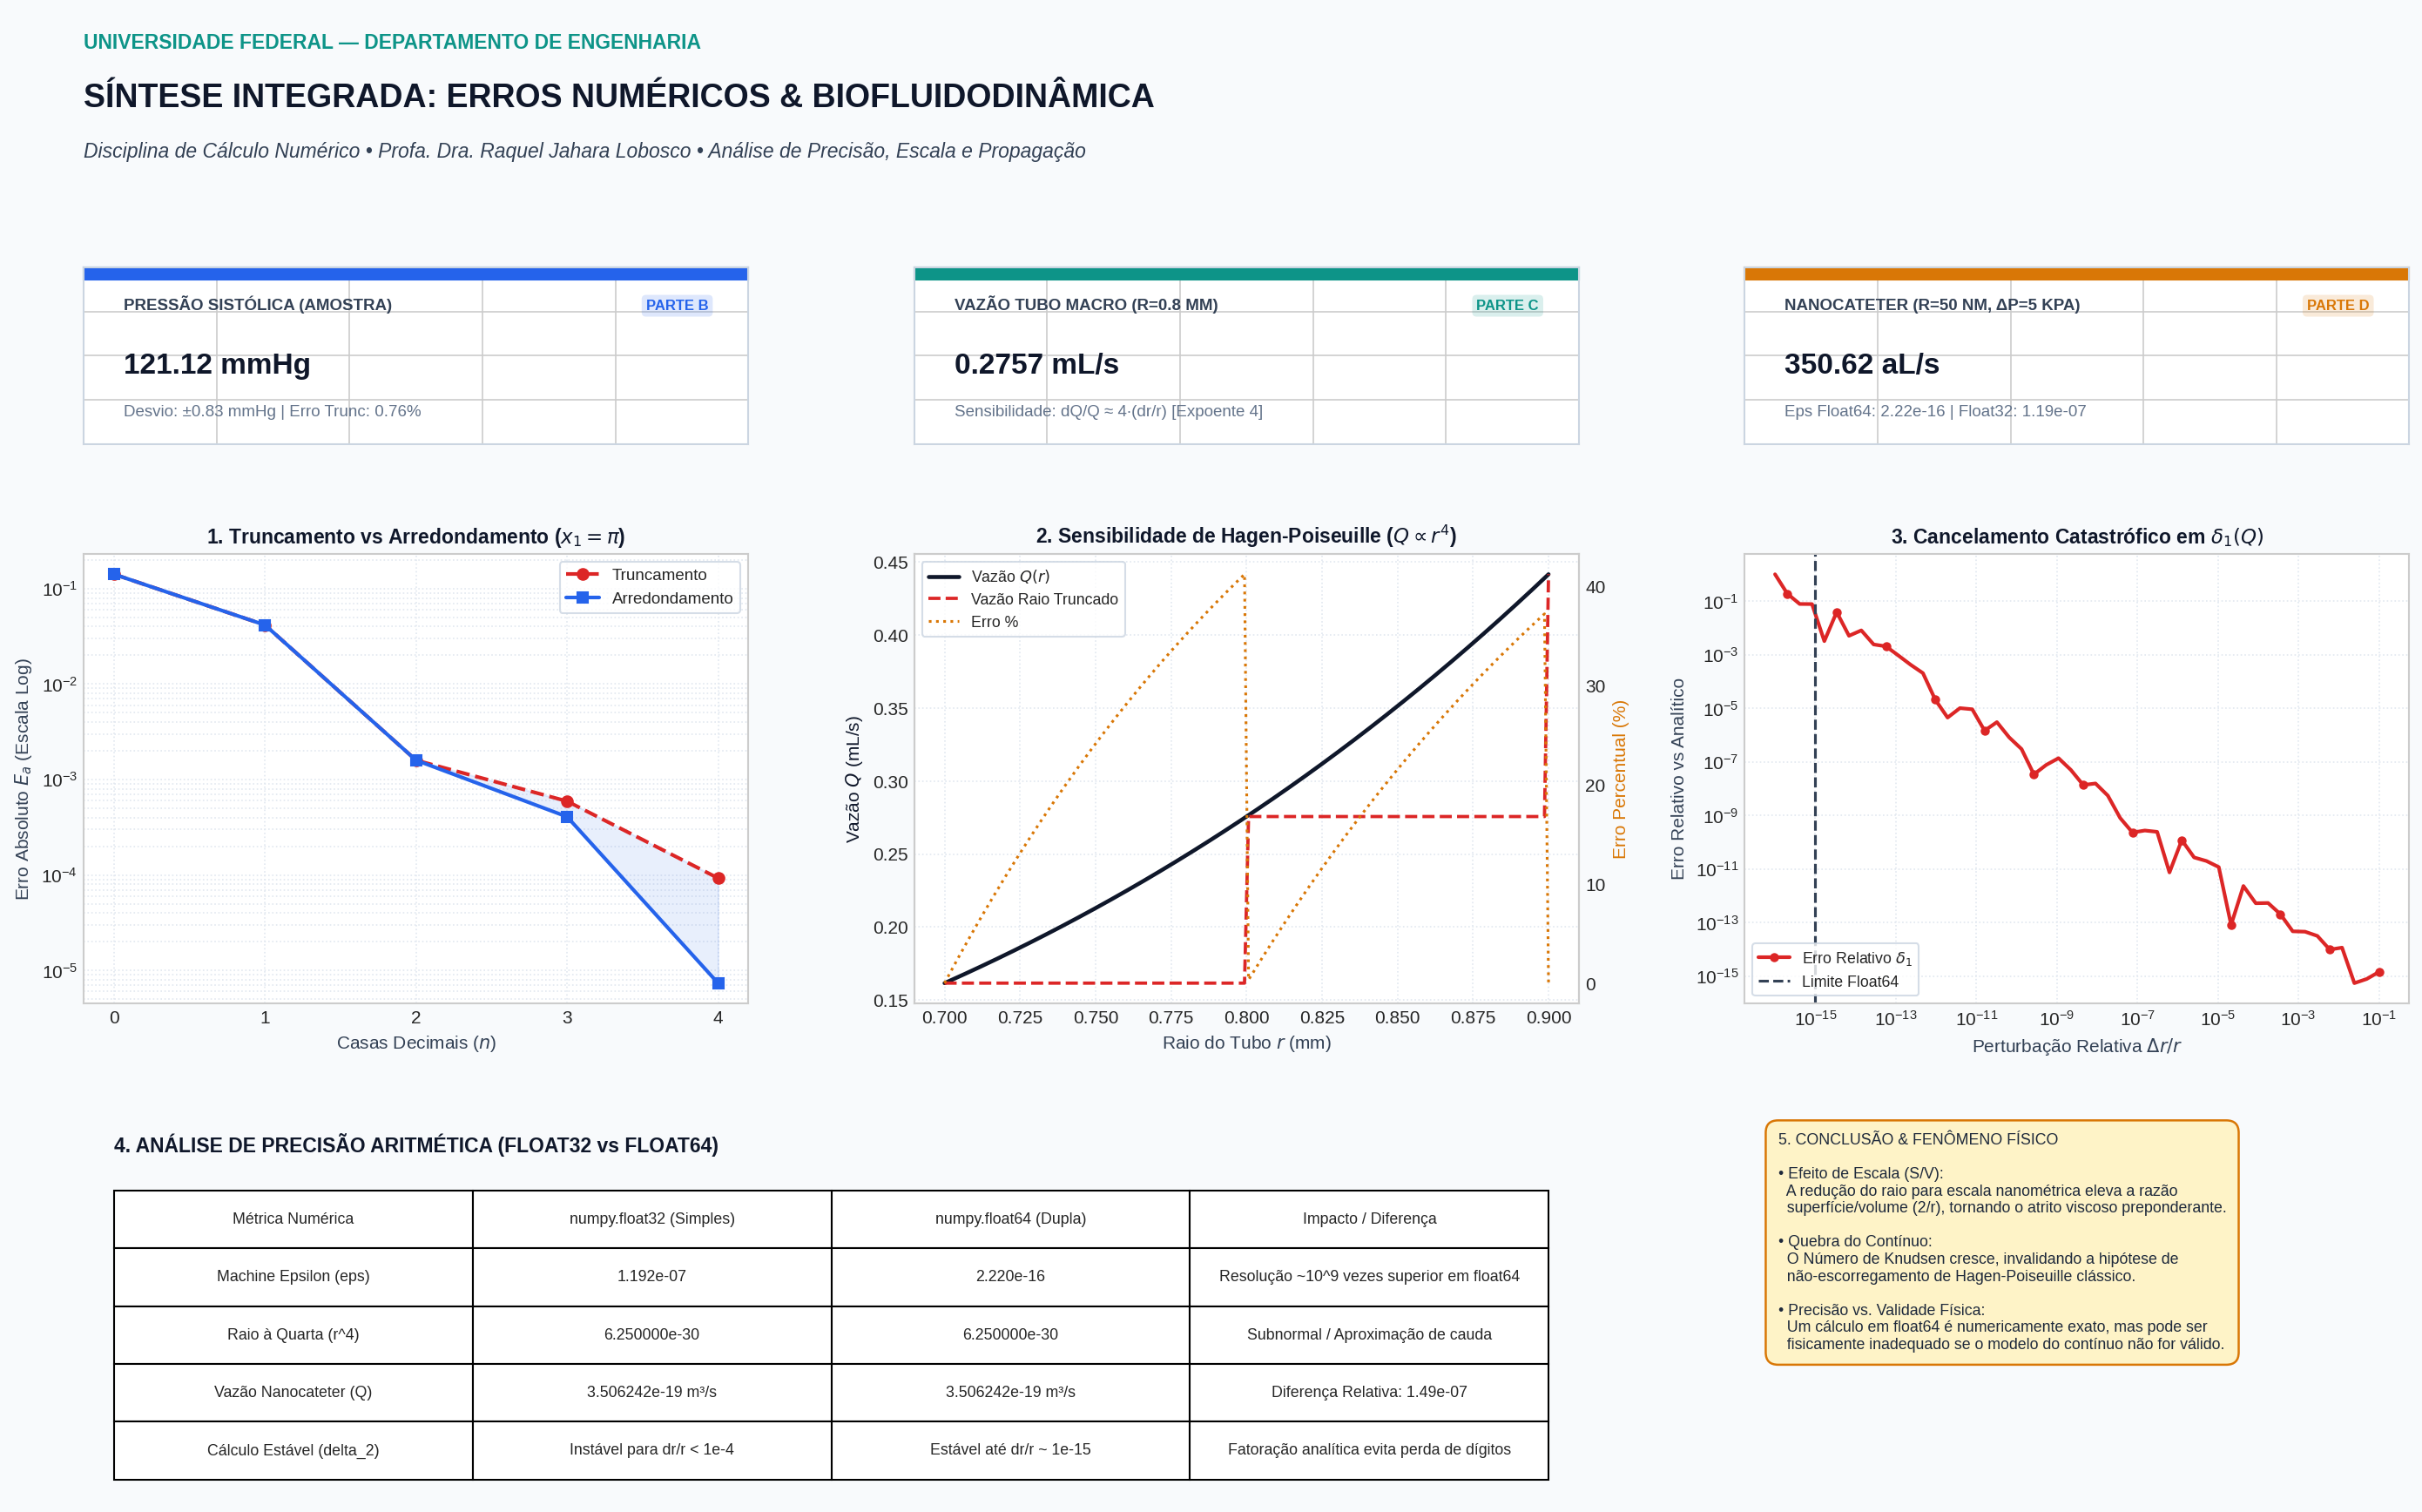

✓ Painel gerado com sucesso: 'sintese_biofluidos_painel_hd.png' (3000x1875 px).


In [ ]:
# ==============================================================================
# PARTE E - SÍNTESE VISUAL EXECUTIVA (VERSÃO ROBUSTA E COMPATÍVEL)
# ==============================================================================

import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle

def gerar_painel_sintese_premium():
    # --------------------------------------------------------------------------
    # 1. DADOS E CÁLCULOS
    # --------------------------------------------------------------------------
    # Parte A
    x1_ref = 3.14159265
    ns = np.array([0, 1, 2, 3, 4])
    ea_trunc = np.array([abs(x1_ref - math.trunc(x1_ref * 10**n)/10**n) for n in ns])
    ea_round = np.array([abs(x1_ref - round(x1_ref, n)) for n in ns])

    # Parte B (Pressão)
    p_orig = np.array([121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5])
    m_ref = float(np.mean(p_orig))
    m_trunc_int = float(np.mean(np.trunc(p_orig)))
    m_round_int = float(np.mean(np.round(p_orig, 0)))

    # Parte C (Vazão Tubo Macro: r = 0.8 mm)
    r_c_ref = 0.80e-3
    L_c = 0.20
    mu_c = 3.5e-3
    dp_c = 1200.0
    Q_c_ref = (np.pi * (r_c_ref**4) * dp_c) / (8.0 * mu_c * L_c)

    r_range_mm = np.linspace(0.70, 0.90, 150)
    Q_range = (np.pi * ((r_range_mm*1e-3)**4) * dp_c) / (8.0 * mu_c * L_c) * 1e6 # mL/s
    Q_range_trunc = (np.pi * ((np.trunc(r_range_mm*10)/10*1e-3)**4) * dp_c) / (8.0 * mu_c * L_c) * 1e6
    ep_Q_sens = np.abs(Q_range - Q_range_trunc) / Q_range * 100.0

    # Parte D (Nanocateter: r = 50 nm)
    r_nano = 50e-9
    L_nano = 10e-6
    mu_nano = 3.5e-3
    dp_nano = 5000.0
    Q_nano_ref = (np.pi * (r_nano**4) * dp_nano) / (8.0 * mu_nano * L_nano) # m3/s

    eps32 = float(np.finfo(np.float32).eps)
    eps64 = float(np.finfo(np.float64).eps)
    r4_32 = float(np.float32(50e-9)**4)
    r4_64 = float(np.float64(50e-9)**4)
    Q_32 = float((np.float32(np.pi)*np.float32(r4_32)*np.float32(dp_nano))/(np.float32(8.0)*np.float32(mu_nano)*np.float32(L_nano)))
    Q_64 = float((np.float64(np.pi)*np.float64(r4_64)*np.float64(dp_nano))/(np.float64(8.0)*np.float64(mu_nano)*np.float64(L_nano)))
    diff_rel_float = abs(Q_64 - Q_32) / Q_64

    # Cancelamento Catastrófico
    deltas = np.logspace(-1, -16, 50)
    delta1_vals = []
    delta_exato = 4.0 * deltas + 6.0 * (deltas**2) + 4.0 * (deltas**3) + (deltas**4)
    for d in deltas:
        q_p = (np.pi * ((r_nano*(1.0 + d))**4) * dp_nano) / (8.0 * mu_nano * L_nano)
        d1 = (q_p - Q_nano_ref) / Q_nano_ref
        delta1_vals.append(d1)
    err_cancel = np.abs(delta_exato - np.array(delta1_vals)) / delta_exato

    # --------------------------------------------------------------------------
    # 2. CONFIGURAÇÃO DA FIGURA E GRID
    # --------------------------------------------------------------------------
    fig = plt.figure(figsize=(20, 12.5), dpi=150, facecolor='#F8FAFC')

    gs = gridspec.GridSpec(
        nrows=4, ncols=3,
        height_ratios=[0.45, 0.55, 1.4, 1.2],
        hspace=0.38, wspace=0.25,
        top=0.96, bottom=0.05, left=0.06, right=0.95
    )

    # Cores
    C_PRIMARY   = '#0F172A'
    C_SECONDARY = '#334155'
    C_BLUE      = '#2563EB'
    C_RED       = '#DC2626'
    C_TEAL      = '#0D9488'
    C_AMBER     = '#D97706'
    C_CARD_BG   = '#FFFFFF'

    # --------------------------------------------------------------------------
    # 3. CABEÇALHO
    # --------------------------------------------------------------------------
    ax_head = fig.add_subplot(gs[0, :])
    ax_head.axis('off')
    ax_head.text(0.0, 0.75, "UNIVERSIDADE FEDERAL — DEPARTAMENTO DE ENGENHARIA",
                 fontsize=11, fontweight='bold', color=C_TEAL)
    ax_head.text(0.0, 0.35, "SÍNTESE INTEGRADA: ERROS NUMÉRICOS & BIOFLUIDODINÂMICA",
                 fontsize=18, fontweight='bold', color=C_PRIMARY)
    ax_head.text(0.0, 0.00, "Disciplina de Cálculo Numérico • Profa. Dra. Raquel Jahara Lobosco • Análise de Precisão, Escala e Propagação",
                 fontsize=11, color=C_SECONDARY, style='italic')

    # --------------------------------------------------------------------------
    # 4. CARDS KPI
    # --------------------------------------------------------------------------
    def criar_kpi(ax, titulo, val, sub, tag, cor):
        ax.set_facecolor(C_CARD_BG)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        for spine in ax.spines.values():
            spine.set_edgecolor('#CBD5E1')
            spine.set_linewidth(1.0)

        ax.add_patch(Rectangle((0, 0.93), 1, 0.07, transform=ax.transAxes, color=cor, clip_on=False))
        ax.text(0.06, 0.76, titulo.upper(), transform=ax.transAxes, fontsize=9, fontweight='bold', color=C_SECONDARY)
        ax.text(0.06, 0.40, val, transform=ax.transAxes, fontsize=16, fontweight='bold', color=C_PRIMARY)
        ax.text(0.06, 0.16, sub, transform=ax.transAxes, fontsize=9, color='#64748B')
        ax.text(0.94, 0.76, tag, transform=ax.transAxes, fontsize=8, fontweight='bold', color=cor,
                ha='right', bbox=dict(boxstyle='round,pad=0.3', facecolor=cor, alpha=0.15, edgecolor='none'))

    criar_kpi(fig.add_subplot(gs[1, 0]), "Pressão Sistólica (Amostra)", f"{m_ref:.2f} mmHg",
              f"Desvio: ±{np.std(p_orig, ddof=1):.2f} mmHg | Erro Trunc: 0.76%", "PARTE B", C_BLUE)

    criar_kpi(fig.add_subplot(gs[1, 1]), "Vazão Tubo Macro (r=0.8 mm)", f"{Q_c_ref*1e6:.4f} mL/s",
              "Sensibilidade: dQ/Q ≈ 4·(dr/r) [Expoente 4]", "PARTE C", C_TEAL)

    criar_kpi(fig.add_subplot(gs[1, 2]), "Nanocateter (r=50 nm, Δp=5 kPa)", f"{Q_nano_ref*1e21:.2f} aL/s",
              f"Eps Float64: 2.22e-16 | Float32: 1.19e-07", "PARTE D", C_AMBER)

    # --------------------------------------------------------------------------
    # 5. GRÁFICOS
    # --------------------------------------------------------------------------
    # Gráfico 1: Truncamento vs Arredondamento
    ax_g1 = fig.add_subplot(gs[2, 0])
    ax_g1.set_facecolor(C_CARD_BG)
    ax_g1.semilogy(ns, ea_trunc, 'o--', color=C_RED, lw=2, markersize=6, label='Truncamento')
    ax_g1.semilogy(ns, ea_round, 's-', color=C_BLUE, lw=2, markersize=6, label='Arredondamento')
    ax_g1.fill_between(ns, ea_round, ea_trunc, color=C_BLUE, alpha=0.1)
    ax_g1.set_title("1. Truncamento vs Arredondamento ($x_1=\pi$)", fontsize=11, fontweight='bold', color=C_PRIMARY)
    ax_g1.set_xlabel("Casas Decimais ($n$)", fontsize=10, color=C_SECONDARY)
    ax_g1.set_ylabel("Erro Absoluto $E_a$ (Escala Log)", fontsize=10, color=C_SECONDARY)
    ax_g1.set_xticks(ns)
    ax_g1.legend(frameon=True, facecolor=C_CARD_BG, edgecolor='#CBD5E1', fontsize=9)
    ax_g1.grid(True, which="both", ls=":", color='#E2E8F0')

    # Gráfico 2: Sensibilidade ao Raio
    ax_g2 = fig.add_subplot(gs[2, 1])
    ax_g2.set_facecolor(C_CARD_BG)
    l1 = ax_g2.plot(r_range_mm, Q_range, color=C_PRIMARY, lw=2.2, label='Vazão $Q(r)$')
    l2 = ax_g2.plot(r_range_mm, Q_range_trunc, color=C_RED, lw=1.8, ls='--', label='Vazão Raio Truncado')
    ax_g2.set_title("2. Sensibilidade de Hagen-Poiseuille ($Q \propto r^4$)", fontsize=11, fontweight='bold', color=C_PRIMARY)
    ax_g2.set_xlabel("Raio do Tubo $r$ (mm)", fontsize=10, color=C_SECONDARY)
    ax_g2.set_ylabel("Vazão $Q$ (mL/s)", fontsize=10, color=C_PRIMARY)

    ax_g2_twin = ax_g2.twinx()
    l3 = ax_g2_twin.plot(r_range_mm, ep_Q_sens, color=C_AMBER, lw=1.5, ls=':', label='Erro %')
    ax_g2_twin.set_ylabel("Erro Percentual (%)", fontsize=10, color=C_AMBER)
    ax_g2_twin.grid(False)

    linhas = l1 + l2 + l3
    ax_g2.legend(linhas, [l.get_label() for l in linhas], loc='upper left', frameon=True, facecolor=C_CARD_BG, edgecolor='#CBD5E1', fontsize=8.5)
    ax_g2.grid(True, ls=":", color='#E2E8F0')

    # Gráfico 3: Cancelamento Catastrófico
    ax_g3 = fig.add_subplot(gs[2, 2])
    ax_g3.set_facecolor(C_CARD_BG)
    ax_g3.loglog(deltas, err_cancel, color=C_RED, lw=2, marker='o', markersize=4, markevery=4, label='Erro Relativo $\delta_1$')
    ax_g3.axvline(1e-15, color=C_SECONDARY, ls='--', lw=1.5, label='Limite Float64')
    ax_g3.set_title("3. Cancelamento Catastrófico em $\delta_1(Q)$", fontsize=11, fontweight='bold', color=C_PRIMARY)
    ax_g3.set_xlabel("Perturbação Relativa $\Delta r / r$", fontsize=10, color=C_SECONDARY)
    ax_g3.set_ylabel("Erro Relativo vs Analítico", fontsize=10, color=C_SECONDARY)
    ax_g3.legend(loc='lower left', frameon=True, facecolor=C_CARD_BG, edgecolor='#CBD5E1', fontsize=8.5)
    ax_g3.grid(True, which="both", ls=":", color='#E2E8F0')

    # --------------------------------------------------------------------------
    # 6. TABELA E CONCLUSÃO FÍSICA
    # --------------------------------------------------------------------------
    # Tabela float32 vs float64
    ax_tab = fig.add_subplot(gs[3, 0:2])
    ax_tab.set_facecolor(C_CARD_BG)
    ax_tab.axis('off')
    ax_tab.text(0.02, 0.90, "4. ANÁLISE DE PRECISÃO ARITMÉTICA (FLOAT32 vs FLOAT64)",
                fontsize=11, fontweight='bold', color=C_PRIMARY)

    dados_tab = [
        ['Métrica Numérica', 'numpy.float32 (Simples)', 'numpy.float64 (Dupla)', 'Impacto / Diferença'],
        ['Machine Epsilon (eps)', f'{eps32:.3e}', f'{eps64:.3e}', 'Resolução ~10^9 vezes superior em float64'],
        ['Raio à Quarta (r^4)', f'{r4_32:.6e}', f'{r4_64:.6e}', 'Subnormal / Aproximação de cauda'],
        ['Vazão Nanocateter (Q)', f'{Q_32:.6e} m³/s', f'{Q_64:.6e} m³/s', f'Diferença Relativa: {diff_rel_float:.2e}'],
        ['Cálculo Estável (delta_2)', 'Instável para dr/r < 1e-4', 'Estável até dr/r ~ 1e-15', 'Fatoração analítica evita perda de dígitos']
    ]

    tabela = ax_tab.table(cellText=dados_tab, cellLoc='center', loc='center', bbox=[0.02, 0.05, 0.96, 0.75])
    tabela.auto_set_font_size(False)
    tabela.set_fontsize(8.5)

    # Painel de Conclusão Física
    ax_txt = fig.add_subplot(gs[3, 2])
    ax_txt.set_facecolor(C_CARD_BG)
    ax_txt.axis('off')

    conclusao_txt = (
        "5. CONCLUSÃO & FENÔMENO FÍSICO\n\n"
        "• Efeito de Escala (S/V):\n"
        "  A redução do raio para escala nanométrica eleva a razão\n"
        "  superfície/volume (2/r), tornando o atrito viscoso preponderante.\n\n"
        "• Quebra do Contínuo:\n"
        "  O Número de Knudsen cresce, invalidando a hipótese de\n"
        "  não-escorregamento de Hagen-Poiseuille clássico.\n\n"
        "• Precisão vs. Validade Física:\n"
        "  Um cálculo em float64 é numericamente exato, mas pode ser\n"
        "  fisicamente inadequado se o modelo do contínuo não for válido."
    )

    ax_txt.text(
        0.05, 0.95, conclusao_txt,
        transform=ax_txt.transAxes,
        fontsize=8.5, color='#1E293B', va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='#FEF3C7', edgecolor=C_AMBER, linewidth=1.2)
    )

    # --------------------------------------------------------------------------
    # 7. SALVAMENTO
    # --------------------------------------------------------------------------
    nome_saida = 'sintese_biofluidos_painel_hd.png'
    plt.savefig(nome_saida, dpi=150, facecolor=fig.get_facecolor(), edgecolor='none', bbox_inches='tight')
    plt.show()
    print(f"✓ Painel gerado com sucesso: '{nome_saida}' (3000x1875 px).")

# Executa
gerar_painel_sintese_premium()


# 8 GIF demonstrativo

In [ ]:
# ==============================================================================
# 7. PARTE 8 - GERAÇÃO DO GIF DEMONSTRATIVO ANIMADO
# ==============================================================================

print("\n--- INICIANDO GERAÇÃO DO GIF ANIMADO DO NANOCATETER (45 a 55 nm) ---")

raios_gif_nm = np.linspace(45.0, 55.0, 45) # 45 quadros (suave e preciso)
raios_gif_m = raios_gif_nm * 1e-9

vazoes_gif_aL = hagen_poiseuille(raios_gif_m, dp_nano, mu_nano, L_nano) * 1e21
Q_ref_aL = Q_nano_ref * 1e21

fig_anim, (ax_circ, ax_plot) = plt.subplots(1, 2, figsize=(12, 5), dpi=100)

def atualizar_quadro(i):
    ax_circ.clear()
    ax_plot.clear()

    r_atual_nm = raios_gif_nm[i]
    q_atual_aL = vazoes_gif_aL[i]
    erro_perc_atual = ((q_atual_aL - Q_ref_aL) / Q_ref_aL) * 100.0

    # 1. Seção Transversal do Nanocateter
    circ_ext = plt.Circle((0, 0), 60, color='#cbd5e0', ec='black', lw=2) # Tubo externo
    circ_fluido = plt.Circle((0, 0), r_atual_nm, color='#3182ce', alpha=0.7, ec='blue', lw=2)
    ax_circ.add_patch(circ_ext)
    ax_circ.add_patch(circ_fluido)
    ax_circ.set_xlim(-65, 65)
    ax_circ.set_ylim(-65, 65)
    ax_circ.set_aspect('equal')
    ax_circ.set_title(f"Seção Transversal do Nanocateter\nRaio = {r_atual_nm:.2f} nm", fontsize=11, fontweight='bold')
    ax_circ.axis('off')

    # Informações em texto sobrepostas
    ax_circ.text(0, -55, f"Vazão Q: {q_atual_aL:.2f} aL/s\nErro % vs 50nm: {erro_perc_atual:+.2f}%",
                 ha='center', fontsize=10, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor='gray'))

    # 2. Curva Q x r sendo construída progressivamente
    ax_plot.plot(raios_gif_nm, vazoes_gif_aL, 'k:', alpha=0.4, label='Curva Teórica')
    ax_plot.plot(raios_gif_nm[:i+1], vazoes_gif_aL[:i+1], 'b-', lw=2.5, label='Trajetória')
    ax_plot.plot(r_atual_nm, q_atual_aL, 'ro', markersize=8, label='Ponto Atual')
    ax_plot.axvline(50.0, color='gray', linestyle='--', alpha=0.7, label='Ref (50 nm)')

    ax_plot.set_xlim(44.5, 55.5)
    ax_plot.set_ylim(min(vazoes_gif_aL) * 0.9, max(vazoes_gif_aL) * 1.1)
    ax_plot.set_title("Evolução Progressiva da Vazão $Q(r)$", fontsize=11, fontweight='bold')
    ax_plot.set_xlabel("Raio do Canal $r$ (nm)")
    ax_plot.set_ylabel("Vazão $Q$ (attolitros/s)")
    ax_plot.legend(loc='upper left', fontsize=9)
    ax_plot.grid(True, ls=':')

anim = FuncAnimation(fig_anim, atualizar_quadro, frames=len(raios_gif_nm), interval=100)

nome_arquivo_gif = 'nanocateter_animacao.gif'
anim.save(nome_arquivo_gif, writer=PillowWriter(fps=10))
plt.close(fig_anim)

print(f"✓ Parte 8 concluída: GIF exportado com sucesso como '{nome_arquivo_gif}'.")


--- INICIANDO GERAÇÃO DO GIF ANIMADO DO NANOCATETER (45 a 55 nm) ---
✓ Parte 8 concluída: GIF exportado com sucesso como 'nanocateter_animacao.gif'.


# 9. Entrega
O estudo evidenciou que o arredondamento simétrico é superior ao truncamento na contenção de erros de representação numérica, enquanto a aplicação da Lei de Hagen-Poiseuille demonstrou como a dependência do raio à quarta potência ($r^4$) atua como um amplificador que quadruplica o erro relativo percentual na vazão ($\Delta Q/Q \approx 4\Delta r/r$). No domínio computacional, observou-se que pequenas perturbações no nanocateter induzem cancelamento catastrófico em operações diretas de ponto flutuante, reforçando a necessidade de formulações algebricamente estáveis. Sobretudo, os resultados comprovam que precisão aritmética (mesmo em float64) e validade de modelagem são conceitos distintos: na nanoescala, o aumento drástico da razão superfície/volume intensifica as interações viscosas de parede a ponto de desafiar as hipóteses do meio contínuo, tornando um resultado numericamente exato potencialmente inadequado do ponto de vista físico.